# CNN CIFAR-10 Classification with Keras - Assignment 1

This notebook implements a **Convolutional Neural Network (CNN)** for the **CIFAR-10** image classification task.

## Goals

- Load and preprocess the **CIFAR-10** dataset
- Train a **CNN** using **Keras 3** with the **TensorFlow backend**
- Evaluate performance on the test set
- Visualize learning curves
- Inspect predictions and class probabilities
- Analyze misclassified images
- Measure training time and parameter count
- Compare results with a **Fully Connected Network (FCN)**

## Notes

- CIFAR-10 images are **32x32 RGB** images with **10 classes**
- This notebook is the **CNN** part of the project

In [144]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import time
import math
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers

from keras.utils import to_categorical

from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [145]:
print("Keras version:", keras.__version__)
print("Backend:", keras.backend.backend())

Keras version: 3.13.2
Backend: tensorflow


In [146]:
# Model / data parameters
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

num_classes = 10
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


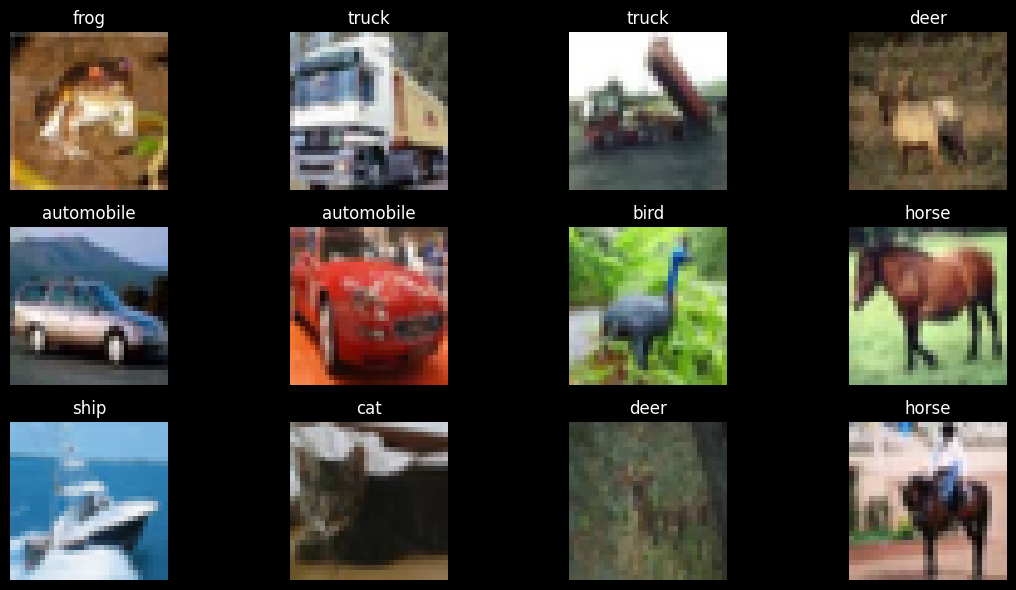

In [147]:
# Show a few sample images from the training set
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing

We normalize the pixel values from `[0, 255]` to `[0, 1]` and apply one-hot encoding to the labels.

In [148]:
# Normalizing
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

#One hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
y_true = np.argmax(y_test, axis=1) # For later use in evaluation

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)

x_train: (50000, 32, 32, 3)
y_train: (50000, 10)
x_test: (10000, 32, 32, 3)


In [149]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
#    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
], name="data_augmentation")

augmenter


<Sequential name=data_augmentation, built=False>

## CNN model

This model includes:
- 3 convolution blocks
- batch normalization within each block
- max pooling
- dropout after each block to manage over- / underfitting (.20, .25, .30, .25)
- a dense classifier head

(.20, .25, .30, .25) acc: 0.8669 loss: 0.8202
(.20, .25, .25, .25) acc: 0.8690 loss: 0.8165
(.20, .25, .25, .225) acc: 0.8608 loss: 0.8377
(.20, .25, .225, .25) acc: 0.8397 loss: 0.8829

(.20, .25, .25, .25) AdamW
Test loss: 0.8133
Test accuracy: 0.8726

(.25, .25, .25, .25) AdamW
Test loss: 0.8083
Test accuracy: 0.8741

In [150]:
inputs = keras.Input(shape=input_shape)

x = augmenter(inputs)

# Convolutional block 1
x = layers.Conv2D(32, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(32, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.20)(x)

# Convolutional block 2
x = layers.Conv2D(64, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(64, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

# Convolutional block 3
x = layers.Conv2D(128, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(128, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation=None)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="cifar10_cnn")

In [151]:
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_63 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_64 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_65 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_66 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,970 (1.24 MB)

 Trainable params: 323,562 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [152]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

## Training

In [153]:
# Training
batch_size = 64
epochs = 50

start_time = time.time()

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks
)

training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

Epoch 1/50


E0000 00:00:1774797421.305955    2357 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cifar10_cnn_1/dropout_36_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.4174 - loss: 1.7620 - val_accuracy: 0.4504 - val_loss: 1.7556 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5671 - loss: 1.4522 - val_accuracy: 0.5406 - val_loss: 1.5340 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6335 - loss: 1.3255 - val_accuracy: 0.6058 - val_loss: 1.4330 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.6774 - loss: 1.2377 - val_accuracy: 0.5895 - val_loss: 1.4622 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.7090 - loss: 1.1760 - val_accuracy: 0.7250 - val_loss: 1.1349 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.7315 - loss: 1.1299 - val_accuracy: 0.7026 - val_loss: 1.2019 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7490 - loss: 1.0947

## Evaluation

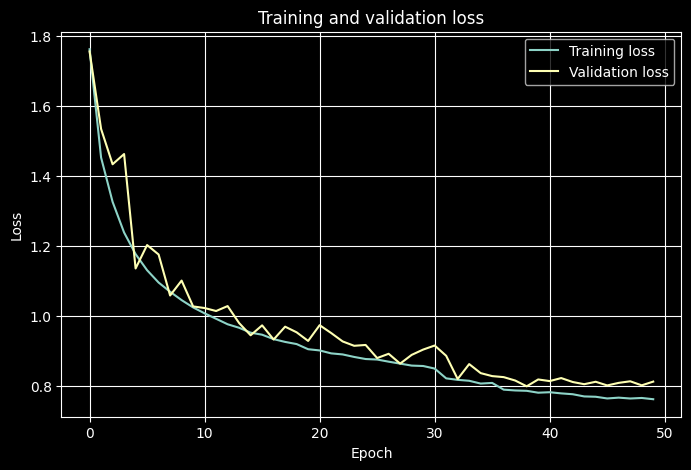

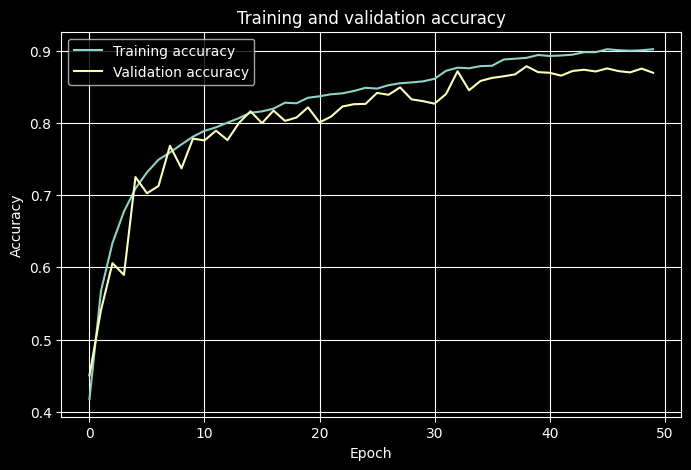

In [154]:
# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [155]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.8083
Test accuracy: 0.8741


In [156]:
# Make predictions on test set
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.87      0.89      0.88      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.87      0.81      0.84      1000
         cat       0.78      0.74      0.76      1000
        deer       0.86      0.85      0.85      1000
         dog       0.86      0.77      0.82      1000
        frog       0.82      0.95      0.88      1000
       horse       0.91      0.90      0.90      1000
        ship       0.93      0.93      0.93      1000
       truck       0.91      0.94      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



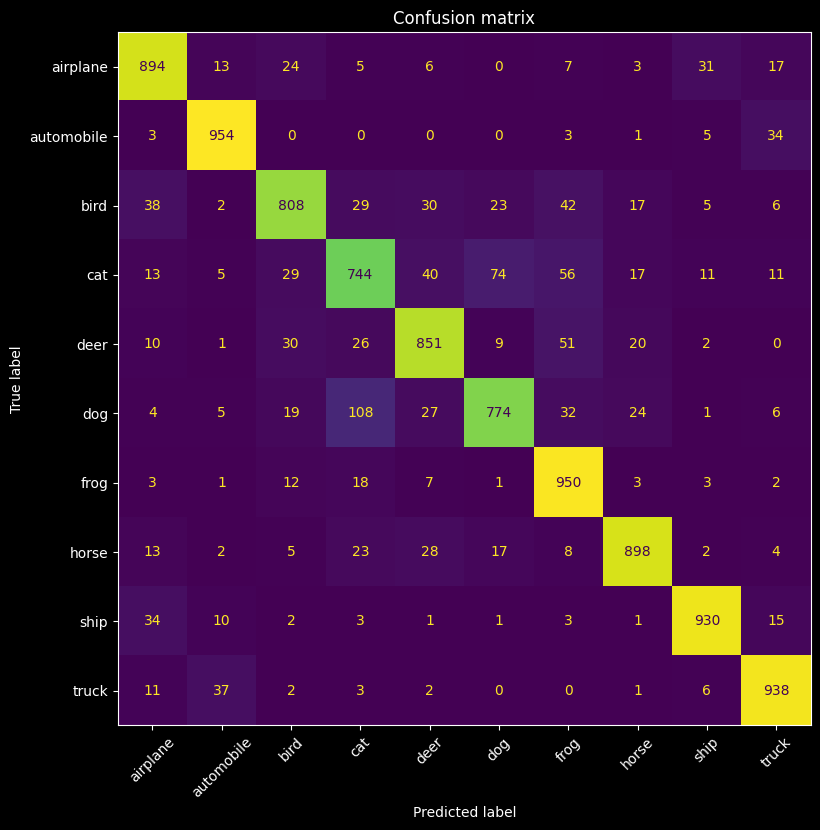

In [157]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title("Confusion matrix")
plt.show()

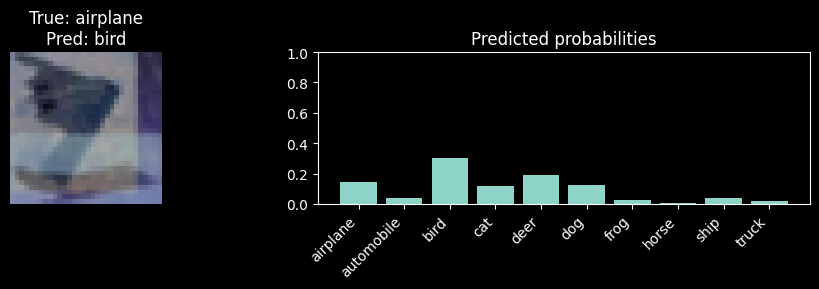

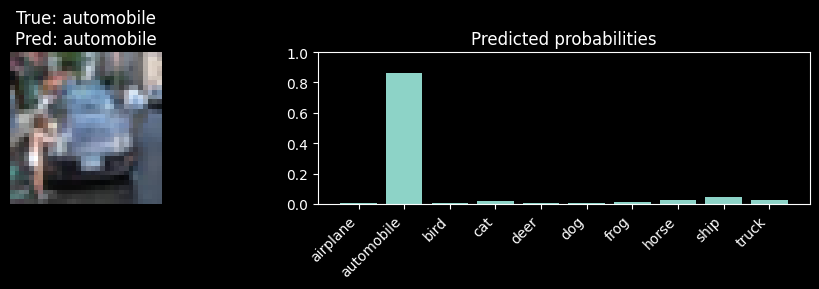

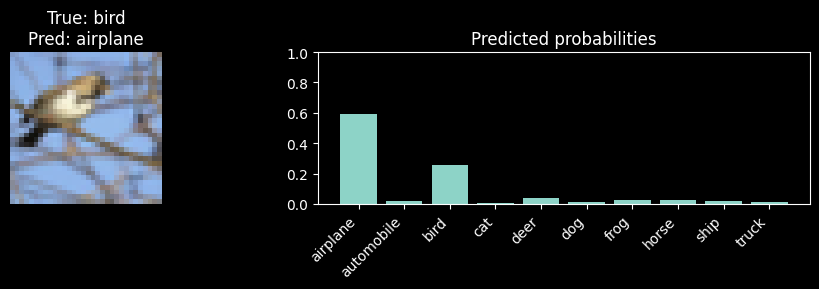

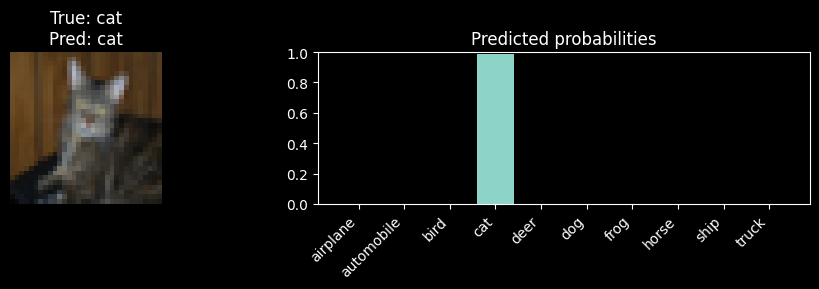

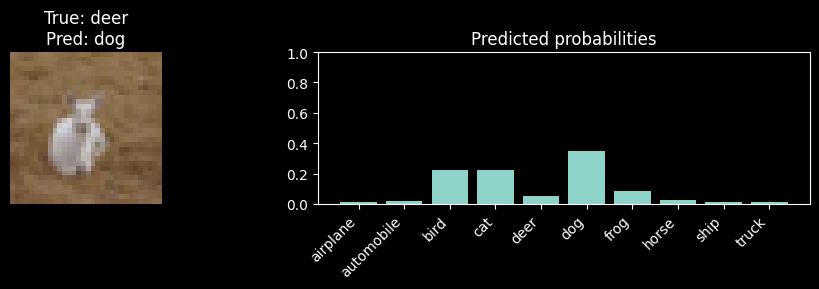

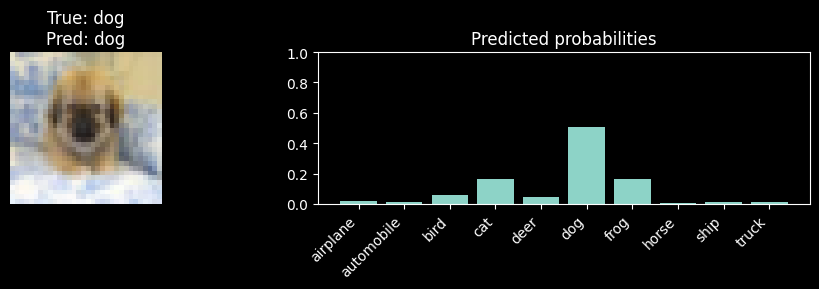

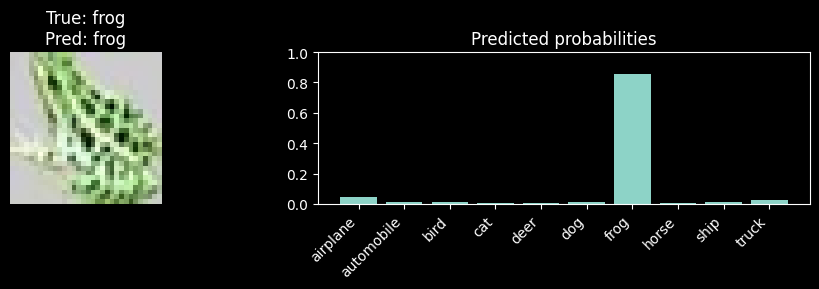

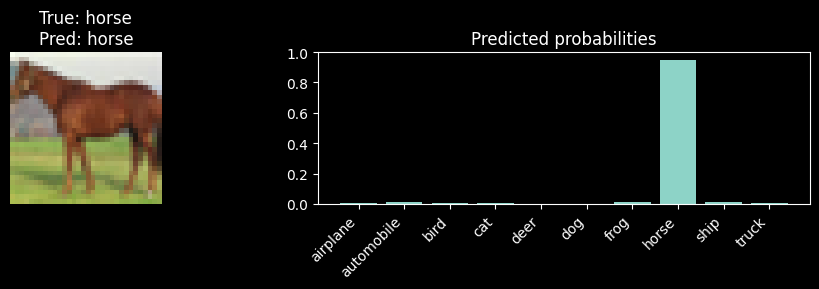

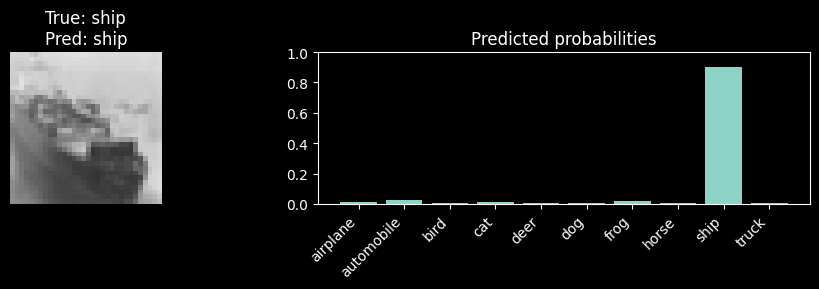

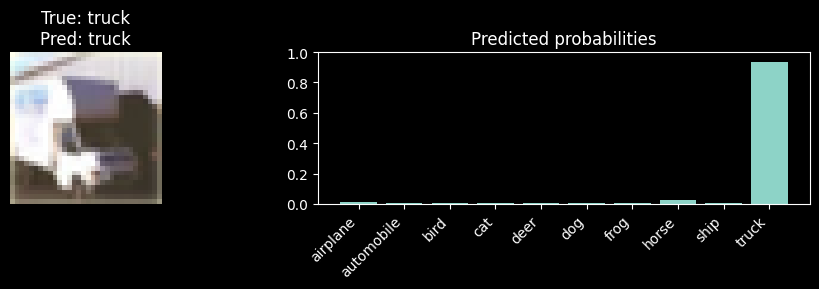

In [158]:
# Show one random example for each true label
indices = [
    np.random.choice(np.where(y_true == class_id)[0])
    for class_id in range(num_classes)
]

for idx in indices:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    axes[0].imshow(x_test[idx])
    axes[0].set_title(
        f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )
    axes[0].axis("off")

    axes[1].bar(range(num_classes), y_prob[idx])
    axes[1].set_xticks(range(num_classes))
    axes[1].set_xticklabels(class_names, rotation=45, ha="right")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Predicted probabilities")

    plt.tight_layout()
    plt.show()

Number of misclassified test images: 1259


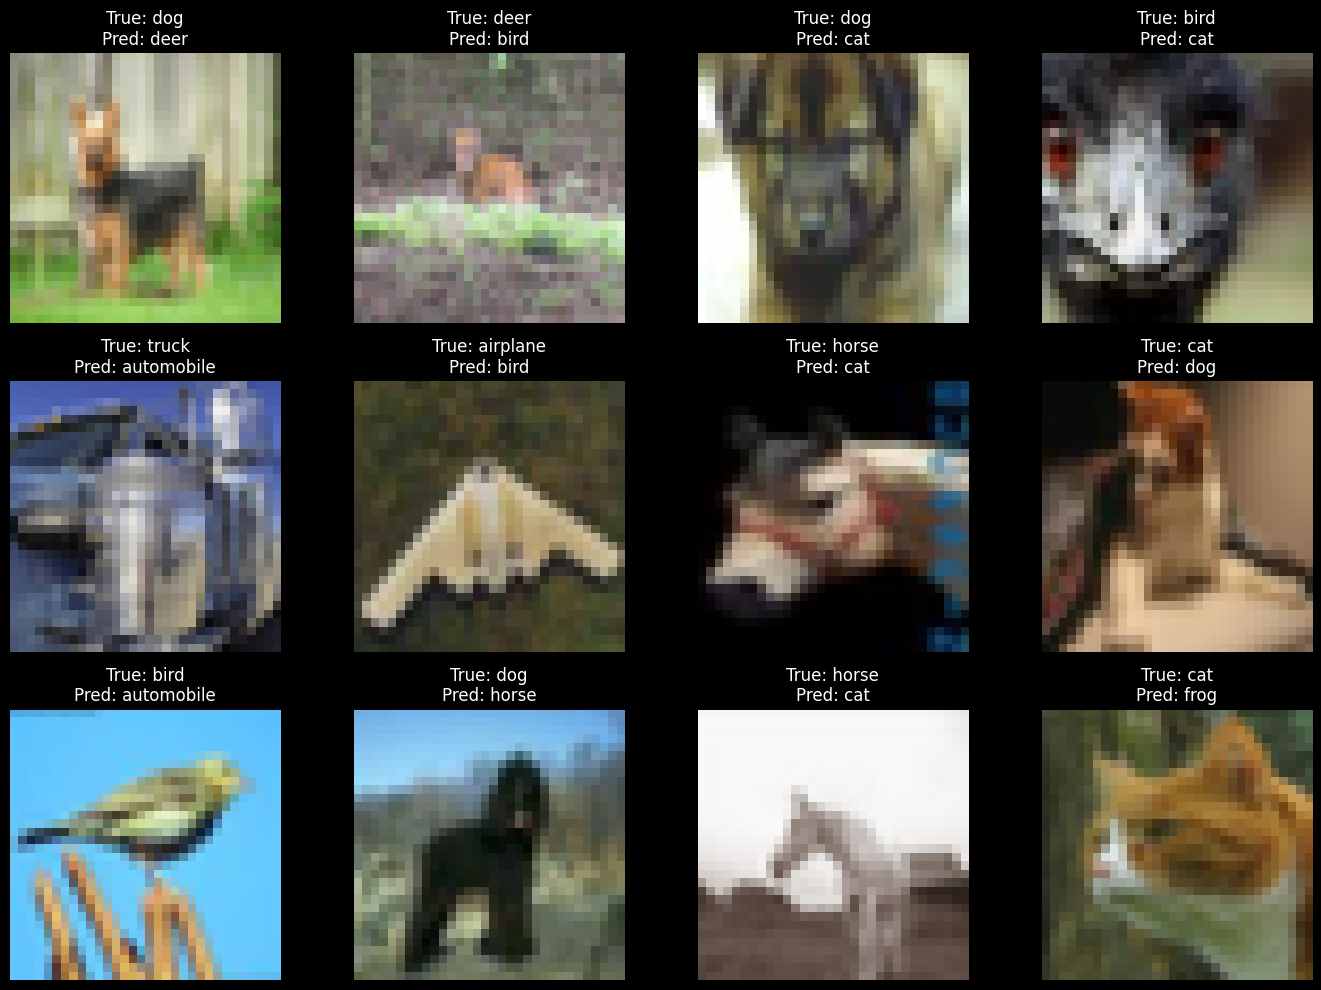

In [159]:
# Analyze misclassified images
misclassified = np.where(y_pred != y_true)[0]
print("Number of misclassified test images:", len(misclassified))

n_show = min(12, len(misclassified))
plt.figure(figsize=(14, 10))
for i, idx in enumerate(misclassified[:n_show]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.title(
        f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

## Experiment summary

The CNN model was improved through several test runs, starting from a simpler base model and gradually adding changes that improved performance.

The first version was a basic CNN with one `Conv2D` layer per block and no batch normalization. The model was then improved by adding a second convolution layer to each block, batch normalization, dropout, and a smaller classifier section using `GlobalAveragePooling2D` instead of `Flatten`.

The final model used three convolutional blocks with filter sizes **32 → 64 → 128**. Each block followed the pattern `Conv2D + BatchNorm + ReLU` twice, followed by max pooling and dropout. This gave better results than the earlier, simpler versions.

Several regularization methods were tested during the experiments. Dropout had a large effect on performance, and finding suitable dropout values was one of the most important and time-consuming parts of the tuning process. With 50 epochs and a batch size of 64, one training run took around 15 minutes. Data augmentation also improved performance, especially random horizontal flipping and small random rotations. Random translations were tested as well, but they reduced performance and were left out of the final setup.

Another useful change was replacing `Flatten` with `GlobalAveragePooling2D`, which reduced the number of parameters and kept the classifier section smaller.

Overall, the final result was reached through repeated testing and gradual improvements rather than from a single training run. The experiments showed that model structure, dropout values, and data augmentation all had a clear impact on the final performance.

In [297]:
os.makedirs("models", exist_ok=True)
model.save("models/cifar10_cnn.keras")
print("Model saved as cifar10_cnn.keras")

Model saved as cifar10_cnn.keras


In [298]:
model = keras.models.load_model("models/cifar10_cnn.keras")
print("Model loaded: cifar10_cnn")

Model loaded: cifar10_cnn
